In [1]:
# Libraries
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pyarrow.dataset as ds

In [2]:
dataset = ds.dataset("dataset", format="parquet")
table = dataset.to_table()
df = table.to_pandas()
df = df[['timestamp', 'out.electricity.net.energy_consumption']]

# Aggregating
df = (
    df.groupby("timestamp")["out.electricity.net.energy_consumption"]
    .sum()
    .reset_index()
)


In [4]:
df.describe()

,timestamp,out.electricity.net.energy_consumption
count,35040,35040.000000
mean,2007-07-02 12:07:30,18.880628
min,2007-01-01 00:15:00,8.542000
25%,2007-04-02 06:11:15,14.398000
50%,2007-07-02 12:07:30,18.283000
75%,2007-10-01 18:03:45,22.632500
max,2008-01-01 00:00:00,39.921000
std,NaN,5.684677


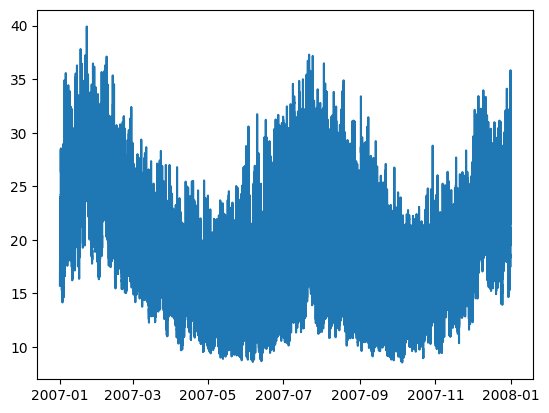

In [5]:
plt.plot(df['timestamp'], df['out.electricity.net.energy_consumption'])

In [4]:
# A year with 15-minute intervals
T = 35040

# Synthetic data
# rng = np.random.default_rng(2025)
# l_agg = 1.2 + 0.3*np.sin(np.linspace(0, 2*np.pi, T)) + 0.05*rng.normal(size=T)

l_agg = df['out.electricity.net.energy_consumption'].values


lhat = np.ones(T)
lhat[0:10] = 0

p0 = 40   # transformer limit in MW
K = 10     # number of curtailment slots allowed

# Residual capacity
c_res = p0 - l_agg

# Dynamic hosting capacity
c_dyn = np.full(T, np.inf)
active = lhat > 1e-12 # to avoid division by zero;
active_idx = np.flatnonzero(active)

c_dyn[active] = c_res[active] / lhat[active]


# Sort active slots by dynamic hosting capacity
sorted_active_local = np.argsort(c_dyn[active])          # indices within active subset
sorted_active_global = active_idx[sorted_active_local]   # map back to original timeline

# (K+1)-th smallest dynamic hosting capacity
C_k = c_dyn[sorted_active_global[K]]

# Intervene at the K slots of lowest dynamic hosting capacity
intervention_idx = sorted_active_global[:K]

u = np.zeros(T, dtype=float)
u[intervention_idx] = c_res[intervention_idx] - C_k * lhat[intervention_idx]

print("C*_K =", C_k)
print("Curtailments --")
for idx in intervention_idx:
    print(f"t={idx:>5d}: u(t) = {u[idx]:.6f} MW")

C*_K = 2.7409999999999997
Curtailments --
t= 2088: u(t) = -2.662000 MW
t= 2092: u(t) = -2.149000 MW
t= 2089: u(t) = -1.970000 MW
t= 2087: u(t) = -1.242000 MW
t= 2093: u(t) = -0.957000 MW
t= 2094: u(t) = -0.919000 MW
t= 1610: u(t) = -0.555000 MW
t= 2091: u(t) = -0.424000 MW
t= 2095: u(t) = -0.175000 MW
t=19365: u(t) = -0.030000 MW


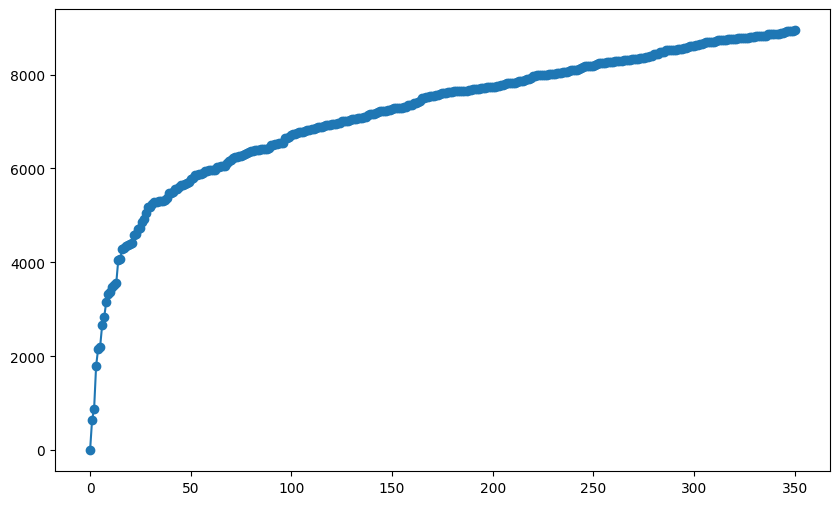

In [17]:
### Plotting

K_max = int(0.01 * T) # plot up to 1% of the time slots with lowest dynamic hosting capacity

active_vals = c_dyn[np.isfinite(c_dyn)]  # Which are not inifinite meaning the lhat is not zero.
sorted_vals = np.sort(active_vals)

C0 = sorted_vals[0]
Ks = np.arange(K_max + 1)
Cstars = sorted_vals[Ks] 
gains_pct = 100 * (Cstars - C0) / C0

plt.figure(figsize=(10, 6))
plt.plot(Ks, gains_pct, marker='o')

In [7]:
## CVAR with no curtailment budget
## Ensuring the expected tail loss is below epsilon with confidence level alpha

# parameters
alpha = 0.95
epsilon = 0


# Decision Variables
C = cp.Variable(nonneg=True, name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, nonneg=True, name="s")

constraints = [
    s >= C * lhat - c_res - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,
    
]

obj = cp.Maximize(C)
problem = cp.Problem(obj, constraints)

problem.solve(solver="ECOS", verbose=True)

print("Optimal C:", C.value)

(CVXPY) Mar 10 01:42:11 PM: Your problem has 35042 variables, 35041 constraints, and 0 parameters.
(CVXPY) Mar 10 01:42:11 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 10 01:42:11 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 10 01:42:11 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 10 01:42:11 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 10 01:42:11 PM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 10 01:42:11 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 10 01:42:11 PM: Applying reduction FlipObjective
(CVXPY) Mar 10 01:42:11 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 10 01:42:11 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 10 01:42:11 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 10 01:42:11 PM: Apply

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 10 01:42:12 PM: Problem status: optimal
(CVXPY) Mar 10 01:42:12 PM: Optimal value: 8.529e+00
(CVXPY) Mar 10 01:42:12 PM: Compilation took 1.207e-01 seconds
(CVXPY) Mar 10 01:42:12 PM: Solver (including time spent in interface) took 3.644e-01 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal C: 8.529103302811137


In [7]:
## CVAR with curtailment budget


alpha = 0.95
epsilon = 0.0
dt = 0.25      # 15-minute intervals
B_mwh = 25.0   # total curtailed energy budget in MWh
mu = 0.2       # max 20% curtailment per timestamp

C = cp.Variable(nonneg=True, name="C")
eta = cp.Variable(name="eta")
s = cp.Variable(T, nonneg=True, name="s")
y = cp.Variable(T, nonneg=True, name="y")

zeta = C * lhat - y - c_res

constraints = [
    s >= zeta - eta,
    eta + (1.0 / ((1.0 - alpha) * T)) * cp.sum(s) <= epsilon,

    y <= C * lhat,          # cannot curtail more than requested load
    y <= mu * C * lhat,     # optional per-slot curtailment cap
    cp.sum(y) * dt <= B_mwh
]

obj = cp.Maximize(C)
problem = cp.Problem(obj, constraints)

problem.solve(solver="ECOS", verbose=True)

print("Optimal C:", C.value)
print("Total curtailed energy (MWh):", y.value.sum() * dt)

(CVXPY) Mar 10 03:17:43 AM: Your problem has 70082 variables, 105122 constraints, and 0 parameters.
(CVXPY) Mar 10 03:17:43 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 10 03:17:43 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 10 03:17:43 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 10 03:17:43 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 10 03:17:43 AM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 10 03:17:43 AM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 10 03:17:43 AM: Applying reduction FlipObjective
(CVXPY) Mar 10 03:17:43 AM: Applying reduction Dcp2Cone
(CVXPY) Mar 10 03:17:43 AM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 10 03:17:43 AM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 10 03:17:43 AM: Appl

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 10 03:17:44 AM: Problem status: optimal
(CVXPY) Mar 10 03:17:44 AM: Optimal value: 8.586e+00
(CVXPY) Mar 10 03:17:44 AM: Compilation took 1.343e-01 seconds
(CVXPY) Mar 10 03:17:44 AM: Solver (including time spent in interface) took 1.258e+00 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Optimal C: 8.586180934919767
Total curtailed energy (MWh): 24.999999999994035


In [19]:
### If you know the capacity of your datacenter, We can propose the minimum generator you need to meet the demand without curtailment.

dt = 0.25 
C_target = 2.0        # The capacity we want.
lambda_y = 1e4        # large penalty to discourage curtailment

# Decision variables
P_gen = cp.Variable(nonneg=True, name="P_gen")     # generator power rating (MW)
p_gen = cp.Variable(T, nonneg=True, name="p_gen")  # generator energy output at every timestep.
y = cp.Variable(T, nonneg=True, name="y")          # curtailment

constraints = [
    p_gen <= P_gen,                 
    y <= C_target * lhat,           
    C_target * lhat - p_gen - y <= c_res
]


objective = cp.Minimize(P_gen + lambda_y * cp.sum(y) * dt)

problem = cp.Problem(objective, constraints)
problem.solve(solver="ECOS", verbose=True)

print("Status:", problem.status)
print("Required generator rating (MW):", P_gen.value)
print("Total curtailed energy (MWh):", np.sum(y.value) * dt)
print("Max curtailment at any step (MW):", np.max(y.value))

(CVXPY) Mar 10 01:53:35 PM: Your problem has 70081 variables, 105120 constraints, and 0 parameters.
(CVXPY) Mar 10 01:53:35 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 10 01:53:35 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 10 01:53:35 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 10 01:53:35 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 10 01:53:35 PM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 10 01:53:35 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 10 01:53:35 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 10 01:53:35 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 10 01:53:35 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Mar 10 01:53:35 PM: Applying reduction ECOS


                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 10 01:53:35 PM: Finished problem compilation (took 2.629e-01 seconds).
(CVXPY) Mar 10 01:53:35 PM: Invoking solver ECOS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


c:\Users\gcsar\anaconda3\envs\RL\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
(CVXPY) Mar 10 01:53:41 PM: Problem status: optimal_inaccurate
(CVXPY) Mar 10 01:53:41 PM: Optimal value: 1.921e+00
(CVXPY) Mar 10 01:53:41 PM: Compilation took 2.629e-01 seconds
(CVXPY) Mar 10 01:53:41 PM: Solver (including time spent in interface) took 5.140e+00 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
Status: optimal_inaccurate
Required generator rating (MW): 1.9210000003052063
Total curtailed energy (MWh): 1.4917331296829353e-13
Max curtailment at any step (MW): 5.966932518731741e-13
